In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt #for ptotting

# For solving ODE numerically (ground truth)
from scipy.integrate import odeint

# Use GPU if available (else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# Mass-spring-damper parameters
m = 1.0          # mass
x0, v0 = 1.0, 0.0   # initial position and velocity

In [3]:
#define system (ODE + forcing )
#external force (currently zero → free vibration)
def F(t):
    return 0*t

# ODE system (converted to first-order form)
def ode_system(y, t, m, c, k):
    x, v = y
    return [v, (-c*v - k*x)/m]

#Get true solution using numerical solver
def get_true(t, m, c, k):
    sol = odeint(ode_system, [x0, v0], t, args=(m, c, k))
    return sol[:, 0]  #return position

In [4]:
#PINN model
# Simple fully-connected neural network
class PINN(nn.Module):
    def __init__(self):
        super().__init__()

        # 3 hidden layers with Tanh activation
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, t):
        return self.net(t)

In [5]:
#training fuction
def train_model(c, k, hard_bc=True,
                lambda_p=1, lambda_bc=10, lambda_d=1,
                epochs=3000):

    model = PINN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Collocation points (physics)
    t_f = torch.linspace(0, 15, 500).view(-1,1).to(device)

    # Data points (supervised)
    t_data = torch.linspace(0, 15, 30).view(-1,1).to(device)

    # True data from numerical solution
    t_np = t_data.cpu().numpy().flatten()
    x_data = torch.tensor(get_true(t_np, m, c, k)).view(-1,1).float().to(device)

    # Initial time (for BC)
    t0 = torch.tensor([[0.0]], requires_grad=True).to(device)

    # Store losses
    phys_l, bc_l, tot_l = [], [], []

    for _ in range(epochs):
        optimizer.zero_grad()
        t_f.requires_grad_(True)

        # Apply hard boundary condition if enabled
        if hard_bc:
            x = x0 + v0*t_f + t_f**2 * model(t_f)
        else:
            x = model(t_f)

        # First and second derivatives
        x_t = torch.autograd.grad(x, t_f, torch.ones_like(x), create_graph=True)[0]
        x_tt = torch.autograd.grad(x_t, t_f, torch.ones_like(x_t), create_graph=True)[0]

        # Physics Loss
        res = m*x_tt + c*x_t + k*x - F(t_f)
        physics_loss = torch.mean(res**2)

        # Boundary Condition Loss
        if hard_bc:
            x0_pred = x0 + v0*t0 + t0**2 * model(t0)
        else:
            x0_pred = model(t0)

        x0_t = torch.autograd.grad(x0_pred, t0,
                                  torch.ones_like(x0_pred),
                                  create_graph=True)[0]

        bc_loss = torch.mean((x0_pred - x0)**2 + (x0_t - v0)**2)

        # Data Loss
        if hard_bc:
            x_d = x0 + v0*t_data + t_data**2 * model(t_data)
        else:
            x_d = model(t_data)

        data_loss = torch.mean((x_d - x_data)**2)

        #Total Loss
        loss = lambda_p*physics_loss + lambda_bc*bc_loss + lambda_d*data_loss

        loss.backward()
        optimizer.step()

        # Store values
        phys_l.append(physics_loss.item())
        bc_l.append(bc_loss.item())
        tot_l.append(loss.item())

    return model, phys_l, bc_l, tot_l

In [6]:
#common time grid for evaluation
t_test = torch.linspace(0, 15, 200).view(-1,1).to(device)
t_np = t_test.cpu().numpy().flatten()

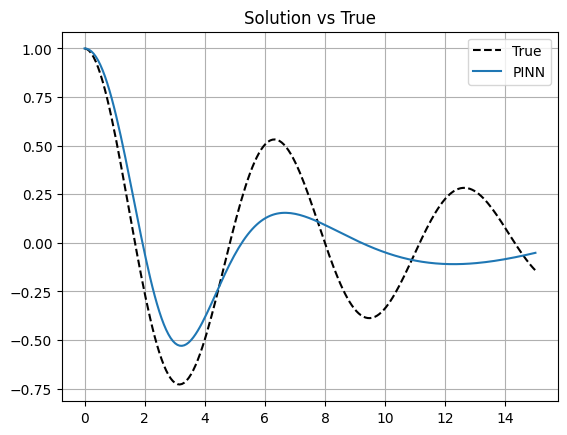

In [7]:
#soltion vs true
model, _, _, _ = train_model(c=0.2, k=1.0)

x_pred = (x0 + v0*t_test + t_test**2 * model(t_test)).detach().cpu().numpy()
x_true = get_true(t_np, m, 0.2, 1.0)

plt.figure()
plt.plot(t_np, x_true, 'k--', label="True")
plt.plot(t_np, x_pred, label="PINN")
plt.title("Solution vs True")
plt.legend(); plt.grid(); plt.show()

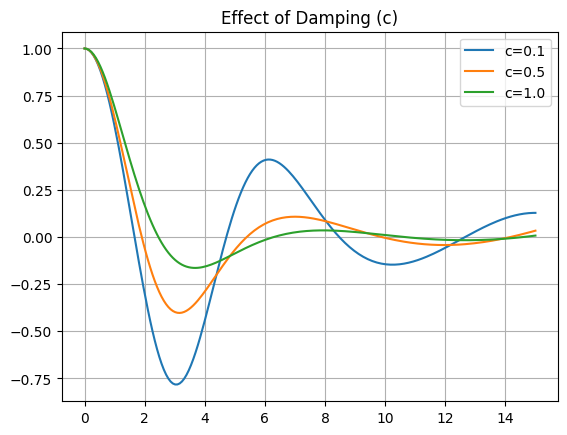

In [8]:
#effect of damping
plt.figure()

for c in [0.1, 0.5, 1.0]:
    model, _, _, _ = train_model(c=c, k=1.0)
    x_pred = (x0 + v0*t_test + t_test**2 * model(t_test)).detach().cpu().numpy()
    plt.plot(t_np, x_pred, label=f"c={c}")

plt.title("Effect of Damping (c)")
plt.legend(); plt.grid(); plt.show()

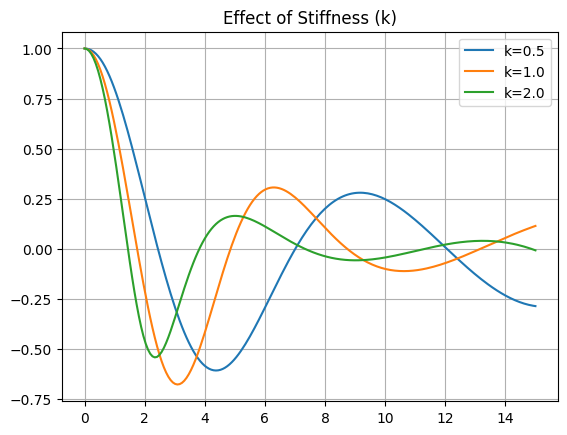

In [9]:
#effect of stiffness(k)
plt.figure()

for k in [0.5, 1.0, 2.0]:
    model, _, _, _ = train_model(c=0.2, k=k)
    x_pred = (x0 + v0*t_test + t_test**2 * model(t_test)).detach().cpu().numpy()
    plt.plot(t_np, x_pred, label=f"k={k}")

plt.title("Effect of Stiffness (k)")
plt.legend(); plt.grid(); plt.show()

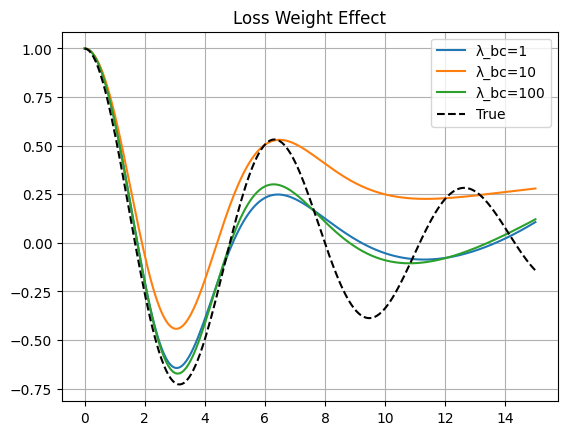

In [10]:
#loss weight tuning
plt.figure()

for lbc in [1, 10, 100]:
    model, _, _, _ = train_model(c=0.2, k=1.0, lambda_bc=lbc)
    x_pred = (x0 + v0*t_test + t_test**2 * model(t_test)).detach().cpu().numpy()
    plt.plot(t_np, x_pred, label=f"λ_bc={lbc}")

plt.plot(t_np, x_true, 'k--', label="True")
plt.title("Loss Weight Effect")
plt.legend(); plt.grid(); plt.show()

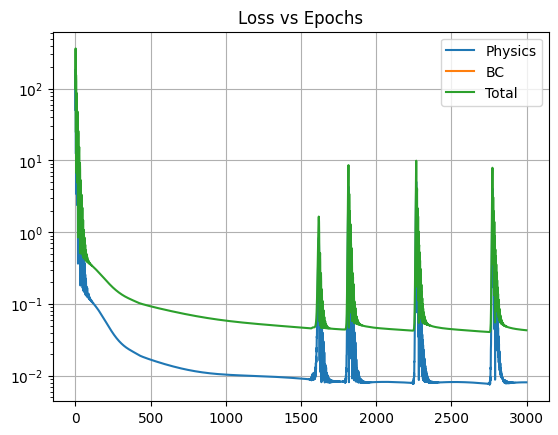

In [11]:
#loss vs epochs
_, phys_l, bc_l, tot_l = train_model(c=0.2, k=1.0)

plt.figure()
plt.plot(phys_l, label="Physics")
plt.plot(bc_l, label="BC")
plt.plot(tot_l, label="Total")
plt.yscale("log")

plt.title("Loss vs Epochs")
plt.legend(); plt.grid(); plt.show()

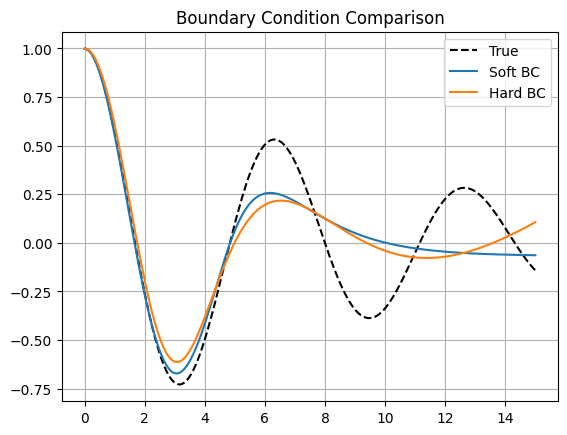

In [12]:
#hard vs soft boundary condition
model_soft, _, _, _ = train_model(c=0.2, k=1.0, hard_bc=False)
model_hard, _, _, _ = train_model(c=0.2, k=1.0, hard_bc=True)

x_soft = model_soft(t_test).detach().cpu().numpy()
x_hard = (x0 + v0*t_test + t_test**2 * model_hard(t_test)).detach().cpu().numpy()

plt.figure()
plt.plot(t_np, x_true, 'k--', label="True")
plt.plot(t_np, x_soft, label="Soft BC")
plt.plot(t_np, x_hard, label="Hard BC")

plt.title("Boundary Condition Comparison")
plt.legend(); plt.grid(); plt.show()

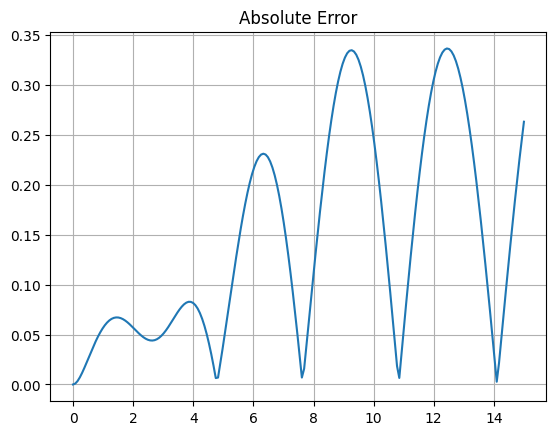

In [13]:
#error plot
error = np.abs(x_true - x_pred.flatten())

plt.figure()
plt.plot(t_np, error)
plt.title("Absolute Error")
plt.grid(); plt.show()